# 04 · Preprocesamiento y reducción de dimensionalidad

**Evento evaluativo 2 – Análisis de Datos (ITM, 2026-2)**
**Fase 3 del proyecto.** Responsable del módulo: Víctor.

El EDA nos dijo qué tiene la base. Este módulo la deja lista para un modelo, y cada paso se apoya en algo que encontramos antes:

1. **Selección de variables:** qué columnas no deben entrar y por qué
2. **Codificación** de variables categóricas: una técnica distinta según la cardinalidad
3. **Transformación y escalado** de variables numéricas: comparación de tres escaladores
4. **PCA:** efecto del escalado, varianza explicada e interpretación de las componentes
5. **Otras técnicas:** t-SNE (no lineal) y LDA (supervisada)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, MinMaxScaler, StandardScaler, RobustScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110
AZUL, NARANJA, GRIS = "#0072B2", "#D55E00", "#6E6E6E"
COLOR_RESULTADO = {"No cancelada": AZUL, "Cancelada": NARANJA}

URL = "https://raw.githubusercontent.com/rfordatascience/tidytuesday/master/data/2020/2020-02-11/hotels.csv"

def limpiar(datos):
    """Decisiones de calidad justificadas en el notebook 02."""
    d = datos.copy()
    d["children"] = d["children"].fillna(0).astype(int)
    d["country"] = d["country"].fillna("Desconocido")
    d["tiene_agente"] = d["agent"].notna().astype(int)
    d["tiene_empresa"] = d["company"].notna().astype(int)
    d["agent"] = d["agent"].fillna(0).astype(int).astype(str)
    d = d.drop(columns="company")
    d["meal"] = d["meal"].replace("Undefined", "SC")
    d["huespedes"] = d["adults"] + d["children"] + d["babies"]
    d["noches"] = d["stays_in_weekend_nights"] + d["stays_in_week_nights"]
    d = d[(d["huespedes"] > 0) & (d["adr"] >= 0) & (d["adr"] < 1000)]
    return d.reset_index(drop=True)


df = limpiar(pd.read_csv(URL))
print("Base limpia:", df.shape)

Base limpia: (119208, 35)


## 1. Selección de variables

Antes de transformar hay que decidir qué entra. Sacamos tres grupos de columnas:

| Columnas | Motivo |
|---|---|
| `reservation_status`, `reservation_status_date` | **Fuga de información:** son el resultado de la reserva con otro nombre. Si `reservation_status = Canceled`, ya sabemos la respuesta. |
| `assigned_room_type`, `required_car_parking_spaces` | **Fuga probable:** se registran o actualizan cuando el huésped llega. En el notebook 03 vimos 0 % de cancelación con parqueadero. |
| `arrival_date_year`, `arrival_date_week_number`, `arrival_date_day_of_month` | El año no se repite en reservas futuras; la semana es redundante con el mes; el día no mostró relación. Conservamos el mes. |
| `huespedes`, `noches` | Las creamos para el EDA; son sumas exactas de otras columnas (redundancia perfecta). |

La variable objetivo `is_canceled` se separa: no se codifica ni se escala, y solo la usamos para colorear las gráficas.

In [2]:
y = df["is_canceled"]
resultado = y.map({0: "No cancelada", 1: "Cancelada"})

excluir = ["is_canceled", "reservation_status", "reservation_status_date", "assigned_room_type",
           "required_car_parking_spaces", "arrival_date_year", "arrival_date_week_number",
           "arrival_date_day_of_month", "huespedes", "noches"]
X = df.drop(columns=excluir).copy()

categoricas = [c for c in X.columns if not pd.api.types.is_numeric_dtype(X[c])]
numericas = [c for c in X.columns if c not in categoricas]

print(f"Variables que entran: {X.shape[1]}  ({len(numericas)} numéricas, {len(categoricas)} categóricas)")
print("\nCardinalidad de las categóricas:")
print(X[categoricas].nunique().sort_values().to_string())

Variables que entran: 25  (15 numéricas, 10 categóricas)

Cardinalidad de las categóricas:
hotel                     2
deposit_type              3
meal                      4
customer_type             4
distribution_channel      5
market_segment            8
reserved_room_type        9
arrival_date_month       12
country                 178
agent                   334


## 2. Codificación de variables categóricas

No existe una codificación que sirva para todo. La elegimos según **cuántas categorías** tiene la variable y **si tienen orden**:

| Variable | Categorías | ¿Orden? | Técnica | Por qué |
|---|---|---|---|---|
| `hotel` | 2 | No | **Label encoding** (0/1) | Con dos categorías no se crea un orden falso |
| `arrival_date_month` | 12 | Sí, y es **cíclico** | **Seno y coseno** | Diciembre y enero deben quedar cerca |
| `meal`, `market_segment`, `distribution_channel`, `deposit_type`, `customer_type`, `reserved_room_type` | 3 a 9 | No | **One-hot encoding** | Pocas categorías sin orden: una columna por categoría |
| `country`, `agent` | 178 y 334 | No | **Codificación por frecuencia** | One-hot crearía más de 500 columnas |

In [3]:
# ¿Por qué no usar label encoding en todas? Ejemplo con el segmento de mercado.
ejemplo = LabelEncoder().fit(X["market_segment"])
mapa = pd.DataFrame({"segmento": ejemplo.classes_, "código": range(len(ejemplo.classes_))})
mapa["% cancelación"] = mapa["segmento"].map(df.groupby("market_segment")["is_canceled"].mean().mul(100).round(0))
print(mapa.to_string(index=False))
print("\nEl código dice que 'Online TA' (6) es 'el triple' de 'Corporate' (2) y que 'Direct' (3) está entre los dos.")
print("Ese orden es alfabético: no significa nada, pero un PCA o un modelo lineal lo tomaría como una magnitud.")

     segmento  código  % cancelación
     Aviation       0           22.0
Complementary       1           12.0
    Corporate       2           19.0
       Direct       3           15.0
       Groups       4           61.0
Offline TA/TO       5           34.0
    Online TA       6           37.0
    Undefined       7          100.0

El código dice que 'Online TA' (6) es 'el triple' de 'Corporate' (2) y que 'Direct' (3) está entre los dos.
Ese orden es alfabético: no significa nada, pero un PCA o un modelo lineal lo tomaría como una magnitud.


In [4]:
X_cod = X.copy()

# a) Label encoding para la variable binaria
codificador_hotel = LabelEncoder()
X_cod["hotel"] = codificador_hotel.fit_transform(X_cod["hotel"])
print("hotel →", dict(zip(codificador_hotel.classes_, codificador_hotel.transform(codificador_hotel.classes_).tolist())))

# b) Codificación cíclica del mes
MESES = {m: i for i, m in enumerate(["January", "February", "March", "April", "May", "June", "July", "August",
                                     "September", "October", "November", "December"], start=1)}
mes = X_cod.pop("arrival_date_month").map(MESES)
X_cod["mes_sen"] = np.sin(2 * np.pi * mes / 12)
X_cod["mes_cos"] = np.cos(2 * np.pi * mes / 12)

# c) Codificación por frecuencia para alta cardinalidad: cada categoría se reemplaza por su proporción en la base
for col in ["country", "agent"]:
    frecuencia = X_cod[col].value_counts(normalize=True)
    X_cod[col + "_frec"] = X_cod[col].map(frecuencia)
    X_cod = X_cod.drop(columns=col)

# d) One-hot encoding para las nominales de baja cardinalidad
one_hot_cols = ["meal", "market_segment", "distribution_channel", "deposit_type", "customer_type", "reserved_room_type"]
codificador_oh = OneHotEncoder(sparse_output=False, handle_unknown="ignore", dtype=int)
matriz_oh = codificador_oh.fit_transform(X_cod[one_hot_cols])
columnas_oh = codificador_oh.get_feature_names_out(one_hot_cols)
X_cod = pd.concat([X_cod.drop(columns=one_hot_cols), pd.DataFrame(matriz_oh, columns=columnas_oh, index=X_cod.index)], axis=1)

print(f"\nColumnas antes de codificar: {X.shape[1]}  →  después: {X_cod.shape[1]}")
print(f"Columnas creadas por one-hot: {len(columnas_oh)}")
print(f"Si country y agent también fueran one-hot: {X_cod.shape[1] - 2 + X['country'].nunique() + X['agent'].nunique()} columnas")

hotel → {'City Hotel': 0, 'Resort Hotel': 1}



Columnas antes de codificar: 25  →  después: 53
Columnas creadas por one-hot: 33
Si country y agent también fueran one-hot: 563 columnas


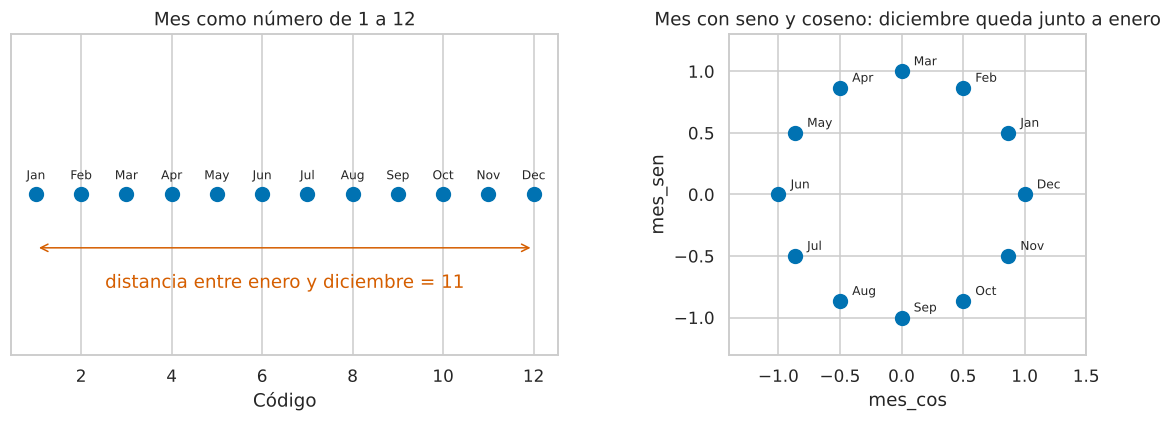

In [5]:
# Efecto de la codificación cíclica: los 12 meses quedan sobre un círculo
angulos = pd.DataFrame({"mes": list(MESES.keys()), "n": list(MESES.values())})
angulos["sen"] = np.sin(2 * np.pi * angulos["n"] / 12)
angulos["cos"] = np.cos(2 * np.pi * angulos["n"] / 12)

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(angulos["n"], [0] * 12, "o", color=AZUL, markersize=9)
for _, f in angulos.iterrows():
    ax[0].annotate(f["mes"][:3], (f["n"], 0), xytext=(0, 10), textcoords="offset points", ha="center", fontsize=8)
ax[0].annotate("", xy=(12, -0.02), xytext=(1, -0.02), arrowprops={"arrowstyle": "<->", "color": NARANJA})
ax[0].text(6.5, -0.035, "distancia entre enero y diciembre = 11", color=NARANJA, ha="center")
ax[0].set(title="Mes como número de 1 a 12", ylim=(-0.06, 0.06), yticks=[], xlabel="Código")

ax[1].plot(angulos["cos"], angulos["sen"], "o", color=AZUL, markersize=9)
for _, f in angulos.iterrows():
    ax[1].annotate(f["mes"][:3], (f["cos"], f["sen"]), xytext=(8, 4), textcoords="offset points", fontsize=8)
ax[1].set(title="Mes con seno y coseno: diciembre queda junto a enero", xlabel="mes_cos", ylabel="mes_sen", aspect="equal",
          xlim=(-1.4, 1.5), ylim=(-1.3, 1.3))
plt.tight_layout()
plt.show()

**Interpretación.**

- Pasamos de **25 a 53 columnas**. El one-hot crea 33. Si hubiéramos usado one-hot también en `country` y `agent` tendríamos 563 columnas, casi todas llenas de ceros.
- La codificación por frecuencia reemplaza cada país por un número que indica qué tan común es. Se pierde detalle, porque dos países con la misma frecuencia quedan iguales, pero Portugal (41 %) queda bien diferenciado de los demás, que es lo que vimos que importa en el EDA.
- En `OneHotEncoder` usamos `handle_unknown="ignore"` para que, si en datos nuevos aparece una categoría que no estaba, no se dañe el proceso: esa fila queda con ceros.
- Con seno y coseno el mes queda sobre un círculo. Si lo dejáramos como número de 1 a 12, diciembre quedaría lo más lejos posible de enero, y en realidad son meses seguidos.

## 3. Transformación y escalado

Las variables numéricas están en escalas muy distintas: `lead_time` va de 0 a 737, `adr` de 0 a 510 y `babies` de 0 a 10. Comparamos tres escaladores sobre `lead_time` y `adr`:

- **MinMaxScaler** (normalización): lleva todo al rango [0, 1] usando el mínimo y el máximo.
- **StandardScaler** (estandarización): resta la media y divide por la desviación estándar.
- **RobustScaler:** resta la mediana y divide por el IQR, así que los extremos no lo afectan.

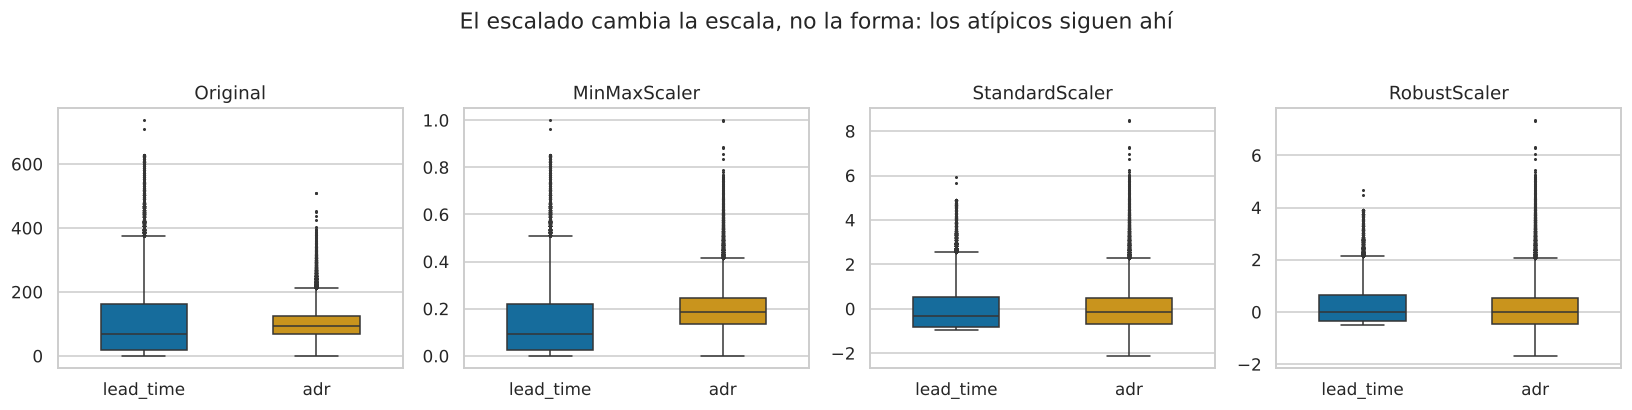

mín     máx   media  desv. est.  mediana
escalador      variable                                            
Original       lead_time  0.00  737.00  104.11      106.88    69.00
               adr        0.00  510.00  101.93       48.04    94.95
MinMaxScaler   lead_time  0.00    1.00    0.14        0.15     0.09
               adr        0.00    1.00    0.20        0.09     0.19
StandardScaler lead_time -0.97    5.92   -0.00        1.00    -0.33
               adr       -2.12    8.49    0.00        1.00    -0.15
RobustScaler   lead_time -0.48    4.67    0.25        0.75     0.00
               adr       -1.68    7.35    0.12        0.85     0.00

In [6]:
escaladores = {"Original": None, "MinMaxScaler": MinMaxScaler(), "StandardScaler": StandardScaler(), "RobustScaler": RobustScaler()}
cols = ["lead_time", "adr"]

fig, ax = plt.subplots(1, 4, figsize=(15, 3.6))
filas = []
for eje, (nombre, esc) in zip(ax, escaladores.items()):
    datos = X_cod[cols] if esc is None else pd.DataFrame(esc.fit_transform(X_cod[cols]), columns=cols)
    sns.boxplot(data=datos, ax=eje, palette=[AZUL, "#E69F00"], width=0.5, fliersize=1)
    eje.set_title(nombre)
    for c in cols:
        filas.append({"escalador": nombre, "variable": c, "mín": datos[c].min(), "máx": datos[c].max(),
                      "media": datos[c].mean(), "desv. est.": datos[c].std(), "mediana": datos[c].median()})
fig.suptitle("El escalado cambia la escala, no la forma: los atípicos siguen ahí", y=1.03)
plt.tight_layout()
plt.show()

pd.DataFrame(filas).set_index(["escalador", "variable"]).round(2)

**Interpretación.**

- Ningún escalador cambia la forma de la distribución ni quita los atípicos, solo cambia las unidades. Para cambiar la forma se necesita una transformación como el logaritmo.
- Con **MinMax** la mediana de `adr` queda en 0,19: casi todos los datos quedan apretados en la parte baja del rango por unas pocas tarifas altas. Es el más sensible a valores extremos.
- **StandardScaler** deja media 0 y desviación estándar 1. Esto es lo que necesita PCA, porque PCA busca las direcciones con más varianza, y si una variable tiene números mucho más grandes va a dominar.
- **RobustScaler** usa la mediana y el IQR, por eso lo afectan menos los extremos, pero no deja todas las variables con la misma varianza.

**Decisión:** aplicamos `log(1 + x)` a las variables de conteo más sesgadas (las que vimos en el notebook 02) y después `StandardScaler` a todas las columnas. `adr` no la transformamos porque el logaritmo la empeoraba.

In [7]:
sesgadas = ["lead_time", "days_in_waiting_list", "previous_cancellations", "previous_bookings_not_canceled", "booking_changes"]

X_trans = X_cod.copy()
antes = X_trans[sesgadas].skew()
X_trans[sesgadas] = np.log1p(X_trans[sesgadas])
print("Asimetría antes y después de log(1 + x):")
print(pd.DataFrame({"antes": antes, "después": X_trans[sesgadas].skew()}).round(2).to_string())

escalador = StandardScaler()
X_esc = pd.DataFrame(escalador.fit_transform(X_trans), columns=X_trans.columns, index=X_trans.index)
print(f"\nMatriz final: {X_esc.shape[0]:,} filas × {X_esc.shape[1]} columnas")
print(f"Media máxima en valor absoluto: {X_esc.mean().abs().max():.1e} | Desviaciones estándar entre {X_esc.std().min():.3f} y {X_esc.std().max():.3f}")

Asimetría antes y después de log(1 + x):
                                antes  después
lead_time                        1.35    -0.87
days_in_waiting_list            11.95     5.75
previous_cancellations          24.44     7.35
previous_bookings_not_canceled  23.54     8.17
booking_changes                  5.50     2.56

Matriz final: 119,208 filas × 53 columnas


Media máxima en valor absoluto: 2.5e-16 | Desviaciones estándar entre 1.000 y 1.000


El logaritmo baja la asimetría en todas, pero en las variables que son cero en más del 95 % de los casos sigue siendo alta. Con tantos ceros no hay transformación que las deje simétricas.

> **Nota.** Aquí ajustamos el escalador con toda la base porque solo estamos explorando. Si después se entrena un modelo, el escalador y las frecuencias se deben calcular solo con los datos de entrenamiento y luego aplicarse a los de prueba.

## 4. Análisis de Componentes Principales (PCA)

PCA construye variables nuevas (componentes) que son combinaciones lineales de las originales, ordenadas de mayor a menor varianza explicada y sin correlación entre sí.

### 4.1 ¿Qué pasa si no se escala?

Sin escalar : la primera componente explica el 81.4 % de la varianza
              y su peso está casi todo en 'lead_time' (0.999) y 'adr' (0.038)
Con escalado: la primera componente explica el 9.4 %


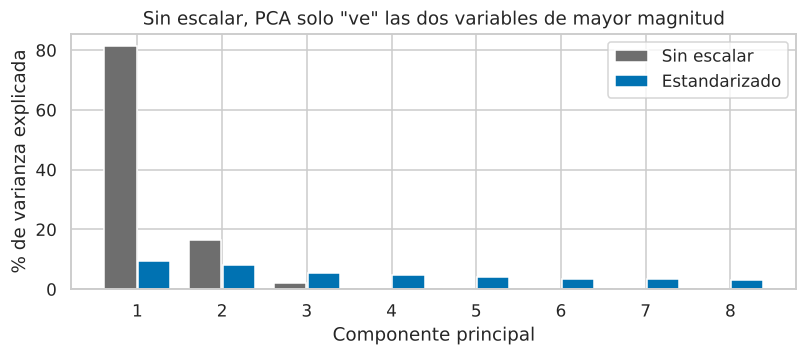

In [8]:
pca_sin = PCA().fit(X_cod)       # datos codificados, sin transformar ni escalar
pca = PCA().fit(X_esc)           # datos transformados y estandarizados

peso_sin = pd.Series(pca_sin.components_[0], index=X_cod.columns).abs().sort_values(ascending=False)
print(f"Sin escalar : la primera componente explica el {100 * pca_sin.explained_variance_ratio_[0]:.1f} % de la varianza")
print(f"              y su peso está casi todo en '{peso_sin.index[0]}' ({peso_sin.iloc[0]:.3f}) y '{peso_sin.index[1]}' ({peso_sin.iloc[1]:.3f})")
print(f"Con escalado: la primera componente explica el {100 * pca.explained_variance_ratio_[0]:.1f} %")

fig, ax = plt.subplots(figsize=(7.5, 3.4))
k = np.arange(1, 9)
ax.bar(k - 0.2, 100 * pca_sin.explained_variance_ratio_[:8], width=0.38, color=GRIS, label="Sin escalar")
ax.bar(k + 0.2, 100 * pca.explained_variance_ratio_[:8], width=0.38, color=AZUL, label="Estandarizado")
ax.set(xlabel="Componente principal", ylabel="% de varianza explicada", title="Sin escalar, PCA solo \"ve\" las dos variables de mayor magnitud")
ax.set_xticks(k)
ax.legend()
plt.tight_layout()
plt.show()

**Interpretación.** Sin escalar, la primera componente explica el 81 % de la varianza. Parece un resultado muy bueno, pero al mirar los pesos vemos que esa componente es prácticamente `lead_time`, que es la variable con los números más grandes. PCA no encontró ninguna estructura, solo siguió las unidades de las variables. Con esto comprobamos por qué hay que escalar antes de aplicar PCA.

### 4.2 Varianza explicada

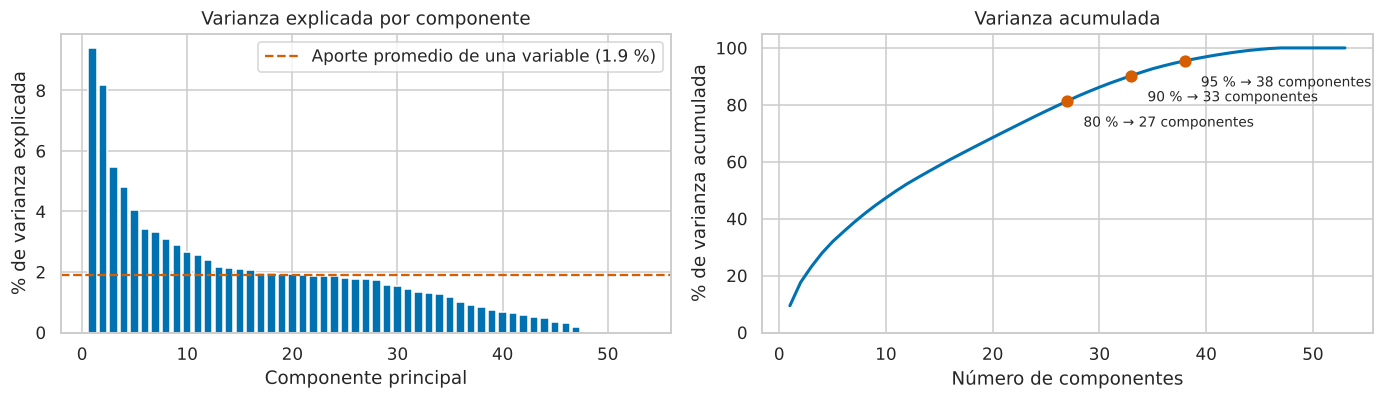

Las 2 primeras componentes explican el 17.6 % de la varianza; las 3 primeras, el 23.1 %.
Componentes necesarias: {80: 27, 90: 33, 95: 38} de 53 columnas
Componentes con varianza mayor al promedio (criterio de Kaiser): 21


In [9]:
var = 100 * pca.explained_variance_ratio_
acum = np.cumsum(var)
necesarias = {umbral: int(np.argmax(acum >= umbral) + 1) for umbral in (80, 90, 95)}

fig, ax = plt.subplots(1, 2, figsize=(13, 3.8))
ax[0].bar(np.arange(1, len(var) + 1), var, color=AZUL)
ax[0].axhline(100 / len(var), color=NARANJA, linestyle="--", label=f"Aporte promedio de una variable ({100 / len(var):.1f} %)")
ax[0].set(xlabel="Componente principal", ylabel="% de varianza explicada", title="Varianza explicada por componente")
ax[0].legend()

ax[1].plot(np.arange(1, len(acum) + 1), acum, color=AZUL, linewidth=2)
for umbral, n in necesarias.items():
    ax[1].plot([n], [acum[n - 1]], "o", color=NARANJA, markersize=7)
    ax[1].annotate(f"{umbral} % → {n} componentes", (n, acum[n - 1]), xytext=(n + 1.5, acum[n - 1] - 9), fontsize=9)
ax[1].set(xlabel="Número de componentes", ylabel="% de varianza acumulada", title="Varianza acumulada", ylim=(0, 105))
plt.tight_layout()
plt.show()

print(f"Las 2 primeras componentes explican el {acum[1]:.1f} % de la varianza; las 3 primeras, el {acum[2]:.1f} %.")
print("Componentes necesarias:", necesarias, f"de {len(var)} columnas")
print(f"Componentes con varianza mayor al promedio (criterio de Kaiser): {(var > 100 / len(var)).sum()}")

**Interpretación.** Con los datos escalados, PCA reduce poco:

- Las dos primeras componentes explican solo el **17,6 %** de la varianza. Para llegar al 80 % se necesitan 27 de las 53 columnas, y para el 95 %, 38.
- Al principio pensamos que habíamos hecho algo mal. Pero después lo relacionamos con el notebook 03, donde las correlaciones entre variables eran bajas (casi todas menores a 0,3). PCA sirve para reducir cuando las variables están muy correlacionadas, y aquí no lo están.
- Parte de la reducción que sí se logra viene del mismo one-hot: por ejemplo, las columnas de `market_segment` y `distribution_channel` dicen cosas parecidas.

En la curva tampoco se ve un "codo" claro.

### 4.3 ¿Qué significan las componentes?

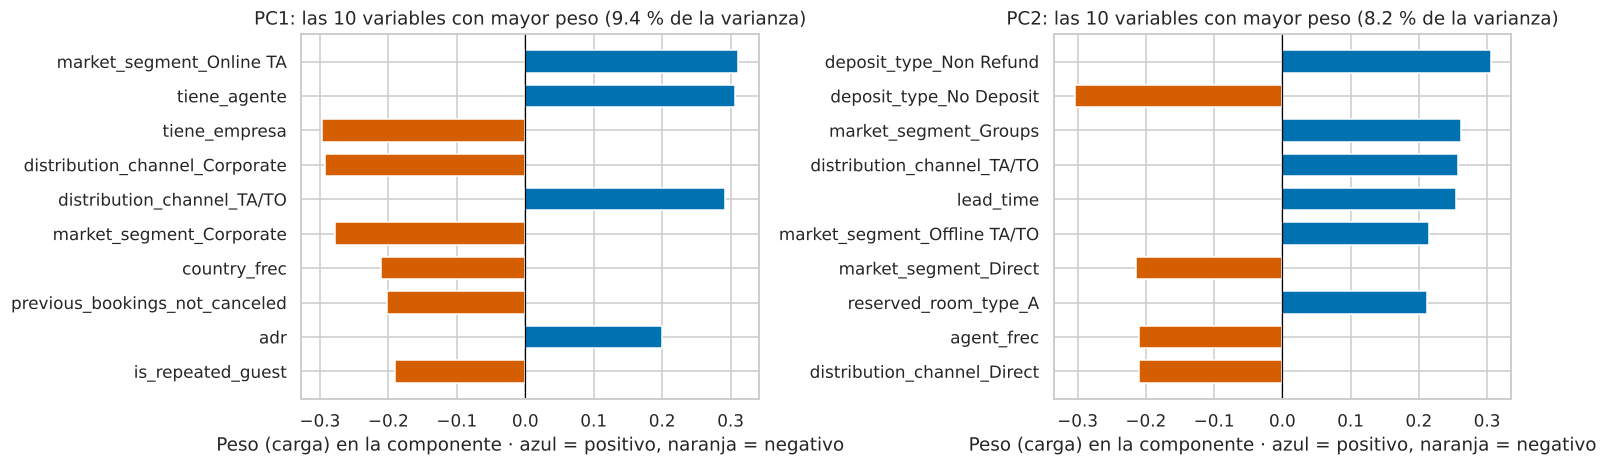

In [10]:
cargas = pd.DataFrame(pca.components_[:2].T, index=X_esc.columns, columns=["PC1", "PC2"])

fig, ax = plt.subplots(1, 2, figsize=(14, 4.4))
for eje, pc in zip(ax, ["PC1", "PC2"]):
    top = cargas[pc].reindex(cargas[pc].abs().sort_values(ascending=False).index).head(10).iloc[::-1]
    eje.barh(top.index, top.values, color=[AZUL if v > 0 else NARANJA for v in top.values], height=0.65)
    eje.axvline(0, color="black", linewidth=0.8)
    eje.set(title=f"{pc}: las 10 variables con mayor peso ({var[int(pc[-1]) - 1]:.1f} % de la varianza)", xlabel="Peso (carga) en la componente · azul = positivo, naranja = negativo")
plt.tight_layout()
plt.show()

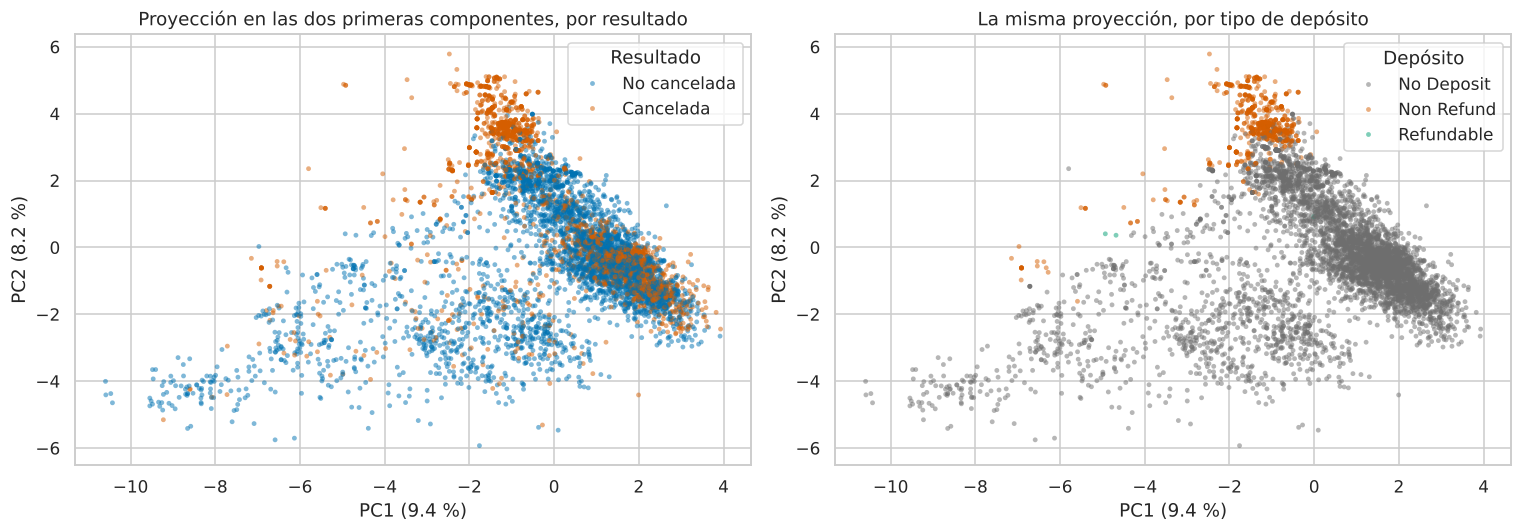

Correlación de cada componente con la cancelación:
  PC1: 0.02   PC2: 0.35

Media de PC2 por tipo de depósito:
Depósito
No Deposit   -0.50
Non Refund    3.54
Refundable    0.88


In [11]:
proyeccion = pd.DataFrame(pca.transform(X_esc)[:, :2], columns=["PC1", "PC2"])
proyeccion["Resultado"] = resultado.values
proyeccion["Depósito"] = df["deposit_type"].values

muestra = proyeccion.sample(6000, random_state=42)

fig, ax = plt.subplots(1, 2, figsize=(14, 5))
sns.scatterplot(data=muestra, x="PC1", y="PC2", hue="Resultado", hue_order=["No cancelada", "Cancelada"],
                palette=COLOR_RESULTADO, s=10, alpha=0.5, linewidth=0, ax=ax[0])
ax[0].set(title="Proyección en las dos primeras componentes, por resultado",
          xlabel=f"PC1 ({var[0]:.1f} %)", ylabel=f"PC2 ({var[1]:.1f} %)")

sns.scatterplot(data=muestra, x="PC1", y="PC2", hue="Depósito", hue_order=["No Deposit", "Non Refund", "Refundable"],
                palette={"No Deposit": GRIS, "Non Refund": NARANJA, "Refundable": "#009E73"}, s=10, alpha=0.5, linewidth=0, ax=ax[1])
ax[1].set(title="La misma proyección, por tipo de depósito", xlabel=f"PC1 ({var[0]:.1f} %)", ylabel=f"PC2 ({var[1]:.1f} %)")
plt.tight_layout()
plt.show()

print("Correlación de cada componente con la cancelación:")
print(f"  PC1: {np.corrcoef(proyeccion['PC1'], y)[0, 1]:.2f}   PC2: {np.corrcoef(proyeccion['PC2'], y)[0, 1]:.2f}")
print("\nMedia de PC2 por tipo de depósito:")
print(proyeccion.groupby("Depósito")["PC2"].mean().round(2).to_string())

**Interpretación.**

- **PC1** parece representar el canal de venta. Con signo positivo pesan `tiene_agente`, *Online TA* y el canal *TA/TO*, y con signo negativo `tiene_empresa` y el canal corporativo. Su correlación con la cancelación es casi cero (0,02).
- **PC2** tiene que ver con las reservas en bloque: pesan *Non Refund*, *Groups* y `lead_time`, que es el mismo perfil del notebook 03. Su correlación con la cancelación es 0,35, más alta que la de cualquier variable original.
- En la gráfica las reservas no reembolsables quedan como una nube separada en la parte de arriba. Nos pareció interesante porque PCA no usa la variable objetivo y aun así separó el mismo grupo que habíamos encontrado en el EDA.
- Las demás reservas, canceladas y no canceladas, quedan mezcladas. Con dos componentes no se alcanzan a separar.

De aquí aprendimos que PCA busca la mayor varianza, no lo que mejor predice: la primera componente es la de más varianza, pero la que más se relaciona con cancelar es la segunda.

> El signo de una componente es arbitrario: con otra versión de la librería el eje puede salir invertido y la nube quedaría abajo, sin que cambie la interpretación.

**Limitaciones.** PCA supone relaciones lineales y está pensado para variables continuas, y aquí 37 de las 53 columnas son de ceros y unos. Lo usamos como herramienta de exploración. Para datos mixtos existen otros métodos (como el análisis de correspondencias múltiples) que no hemos visto y quedan para después.

## 5. Otras técnicas de reducción

Para contrastar, aplicamos una técnica **no lineal** (t-SNE) y una **supervisada** (LDA).

- **t-SNE** conserva las vecindades locales: puntos parecidos quedan juntos. No conserva distancias globales y es costoso, así que lo aplicamos a una muestra de 4.000 reservas.
- **LDA** sí usa la variable objetivo: busca la dirección que mejor separa las clases. Con dos clases produce una sola dimensión.

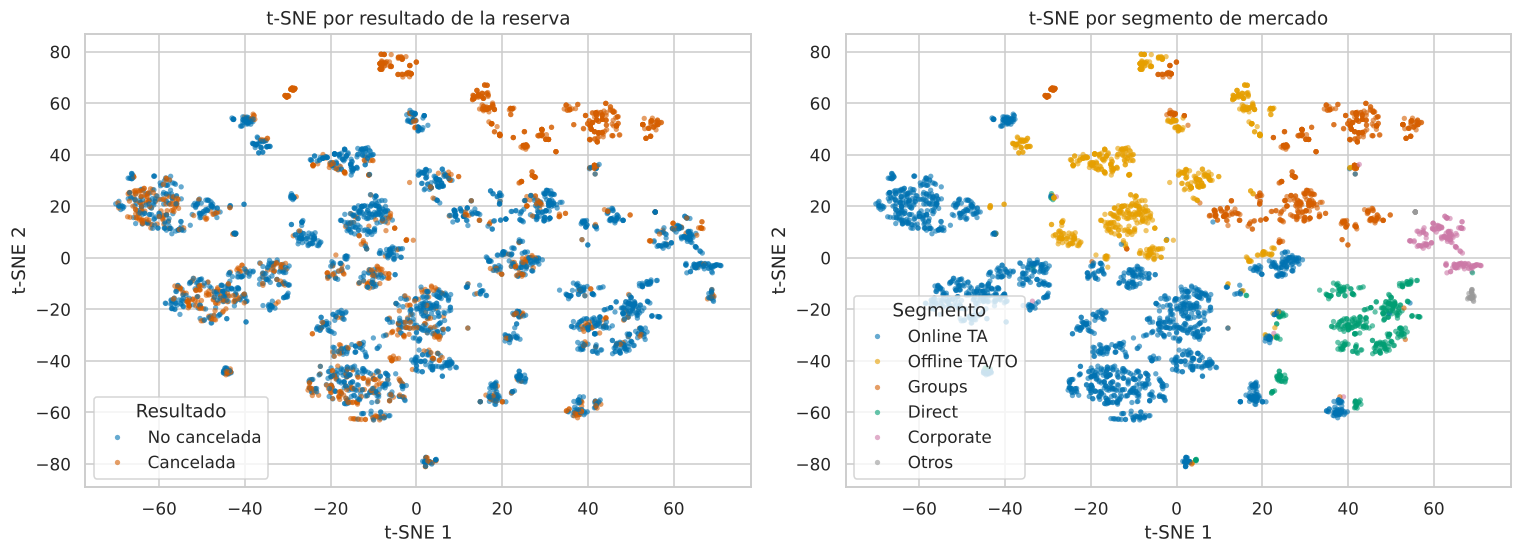

In [12]:
indices = X_esc.sample(4000, random_state=42).index

tsne = TSNE(n_components=2, perplexity=30, init="pca", random_state=42)
embedding = pd.DataFrame(tsne.fit_transform(X_esc.loc[indices]), columns=["t-SNE 1", "t-SNE 2"], index=indices)
embedding["Resultado"] = resultado.loc[indices]
embedding["Segmento"] = df.loc[indices, "market_segment"]

fig, ax = plt.subplots(1, 2, figsize=(14, 5.2))
sns.scatterplot(data=embedding, x="t-SNE 1", y="t-SNE 2", hue="Resultado", hue_order=["No cancelada", "Cancelada"],
                palette=COLOR_RESULTADO, s=12, alpha=0.6, linewidth=0, ax=ax[0])
ax[0].set_title("t-SNE por resultado de la reserva")

principales = ["Online TA", "Offline TA/TO", "Groups", "Direct", "Corporate"]
embedding["Segmento"] = embedding["Segmento"].where(embedding["Segmento"].isin(principales), "Otros")
sns.scatterplot(data=embedding, x="t-SNE 1", y="t-SNE 2", hue="Segmento", hue_order=principales + ["Otros"],
                palette=["#0072B2", "#E69F00", "#D55E00", "#009E73", "#CC79A7", "#999999"], s=12, alpha=0.6, linewidth=0, ax=ax[1])
ax[1].set_title("t-SNE por segmento de mercado")
plt.tight_layout()
plt.show()

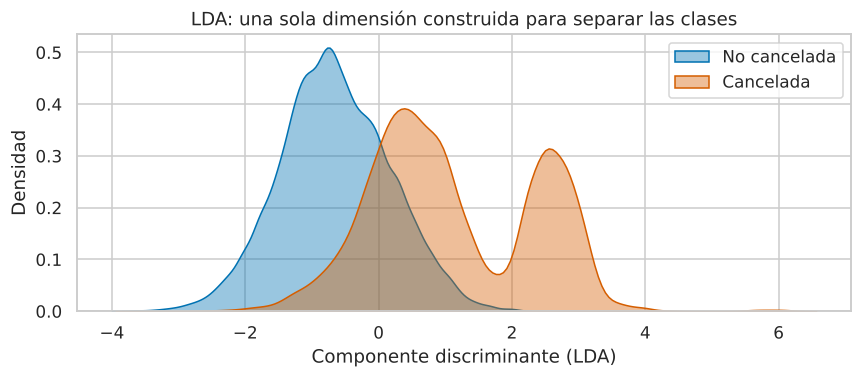

Variables con mayor peso en la dirección discriminante:
country_frec                 1.01
lead_time                    0.85
agent_frec                   0.75
total_of_special_requests   -0.73
deposit_type_Non Refund      0.53
deposit_type_No Deposit     -0.51

Correlación del eje LDA con la cancelación: 0.65  (PC2 tenía 0,35)


In [13]:
lda = LinearDiscriminantAnalysis(n_components=1)
eje_lda = lda.fit_transform(X_esc, y).ravel()

fig, ax = plt.subplots(figsize=(8, 3.6))
for nombre, color in COLOR_RESULTADO.items():
    sns.kdeplot(eje_lda[(resultado == nombre).values], fill=True, alpha=0.4, color=color, label=nombre, ax=ax, clip=(-4, 8))
ax.set(xlabel="Componente discriminante (LDA)", ylabel="Densidad", title="LDA: una sola dimensión construida para separar las clases")
ax.legend(title="")
plt.tight_layout()
plt.show()

pesos_lda = pd.Series(lda.coef_[0], index=X_esc.columns)
print("Variables con mayor peso en la dirección discriminante:")
print(pesos_lda.reindex(pesos_lda.abs().sort_values(ascending=False).index).head(6).round(2).to_string())
print(f"\nCorrelación del eje LDA con la cancelación: {np.corrcoef(eje_lda, y)[0, 1]:.2f}  (PC2 tenía 0,35)")

**Interpretación.**

- En **t-SNE** los datos se ven en grupos separados, y al colorear por segmento de mercado vemos que esos grupos corresponden sobre todo al segmento, no a la cancelación. En varios grupos hay mezcla de canceladas y no canceladas, y otros (los de *Groups*) son casi todos de canceladas.
- Con t-SNE hay que tener cuidado: el tamaño de los grupos y la distancia entre ellos no se pueden interpretar, y el resultado cambia con la perplejidad y la semilla. Sirve para ver agrupaciones, no para medir.
- **LDA** separa las clases mejor que PCA con una sola dimensión (correlación de 0,65 con la cancelación, frente a 0,35 de PC2). Eso es esperable porque LDA sí usa la etiqueta. Las variables que más pesan son el país, la anticipación, las solicitudes especiales y el depósito, las mismas que salieron en el EDA. Creemos que el segundo pico de la curva naranja corresponde a las reservas no reembolsables.

| Técnica | Tipo | Usa la etiqueta | Qué vimos |
|---|---|---|---|
| PCA | Lineal | No | Reduce poco; PC2 separa las reservas en bloque |
| t-SNE | No lineal | No | Grupos definidos por el segmento de mercado |
| LDA | Lineal | Sí | La mejor separación en una dimensión |

## Cierre del módulo

1. Sacamos nueve columnas por fuga de información o porque eran redundantes.
2. Usamos cuatro tipos de codificación según la variable, y pasamos de 25 a 53 columnas (con one-hot en todo habrían sido 563).
3. Comparamos tres escaladores y nos quedamos con logaritmo y estandarización.
4. PCA reduce poco en esta base (27 componentes para el 80 %), lo que coincide con las correlaciones bajas del EDA.
5. Las tres técnicas muestran a las reservas no reembolsables como el grupo más diferente, igual que en el EDA.

Queda una matriz de 119.208 filas por 53 columnas lista para un modelo. Recomendamos comparar los resultados con y sin filas repetidas.